### Step 1 — Project setup and imports

In [38]:
# Core imports
import numpy as np
from pathlib import Path
import sys
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Base paths
PROJECT_ROOT = Path("..")
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"

# Allow imports from ../src
sys.path.append(str(PROJECT_ROOT / "src"))

# Import our utilities
from bbo_utils import (
    load_xy,
    fit_gp,
    acquisition_ucb,
    generate_random_candidates,
    format_submission,
    validate_submission_string,
)

#from candidates import generate_random_candidates

### Step 2 — Load and validate initial data

In [39]:
for func_id in range(1, 9):
    X, y = load_xy(func_id, DATA_RAW_DIR)

    print(
        f"Function {func_id}: "
        f"X shape={X.shape}, "
        f"y shape={y.shape}, "
        f"X range=({X.min():.6f}, {X.max():.6f}), "
        f"y range=({y.min():.6f}, {y.max():.6f})"
    )



Function 1: X shape=(10, 2), y shape=(10,), X range=(0.078723, 0.883890), y range=(-0.003606, 0.000000)
Function 2: X shape=(10, 2), y shape=(10,), X range=(0.028698, 0.926564), y range=(-0.065624, 0.611205)
Function 3: X shape=(15, 3), y shape=(15,), X range=(0.046809, 0.990882), y range=(-0.398926, -0.034835)
Function 4: X shape=(30, 4), y shape=(30,), X range=(0.006250, 0.999483), y range=(-32.625660, -4.025542)
Function 5: X shape=(20, 4), y shape=(20,), X range=(0.038193, 0.957644), y range=(0.112940, 1088.859618)
Function 6: X shape=(20, 5), y shape=(20,), X range=(0.004911, 0.978806), y range=(-2.571170, -0.714265)
Function 7: X shape=(30, 6), y shape=(30,), X range=(0.003635, 0.998655), y range=(0.002701, 1.364968)
Function 8: X shape=(40, 8), y shape=(40,), X range=(0.003419, 0.998885), y range=(5.592193, 9.598482)


In [40]:
# Week 1 submitted inputs (portal)
WEEK1_INPUTS = {
    1: [0.705738, 0.871990],
    2: [0.828497, 0.970137],
    3: [0.418575, 0.366581, 0.521443],
    4: [0.370752, 0.426131, 0.337047, 0.465539],
    5: [0.398348, 0.896184, 0.926939, 0.972836],
    6: [0.296485, 0.322087, 0.332446, 0.760368, 0.040944],
    7: [0.033169, 0.329738, 0.366358, 0.234301, 0.286315, 0.704927],
    8: [0.147947, 0.193825, 0.060981, 0.008004, 0.719306, 0.453461, 0.045592, 0.938970],
}

# Week 1 observed outputs (email)
WEEK1_OUTPUTS = {
    1: 8.994904739436242e-46,
    2: 0.07492805470733854,
    3: -0.013221116845993724,
    4: -0.4713345507601363,
    5: 2360.0402820167205,
    6: -0.49886770748675036,
    7: 2.4608579737515917,
    8: 9.894432442301,
}

# Week 2 submitted inputs (portal)
WEEK2_INPUTS = {
    1: [0.763923, 0.799245],
    2: [0.692932, 0.920964],
    3: [0.388137, 0.056619, 0.408877],
    4: [0.413742, 0.470182, 0.290309, 0.439853],
    5: [0.901642, 0.984569, 0.982367, 0.952999],
    6: [0.347816, 0.270027, 0.588964, 0.987295, 0.290167],
    7: [0.196139, 0.369342, 0.400707, 0.230683, 0.233984, 0.607869],
    8: [0.078187, 0.158932, 0.026599, 0.138226, 0.529417, 0.076738, 0.059868, 0.118162],
}

# Week 2 observed outputs (email)
WEEK2_OUTPUTS = {
    1: 1.1451214454803375e-33,
    2: 0.5227732568346157,
    3: -0.08200213652671233,
    4: -1.7902558622959037,
    5: 5823.4794607079075,
    6: -0.6884064929199594,
    7: 2.425181219664537,
    8: 9.6885056366981,
}

# Week 3 submitted inputs (portal)
WEEK3_INPUTS = {
    1: [0.773956, 0.438878],
    2: [0.773956, 0.438878],
    3: [0.708862, 0.999390, 0.007483],
    4: [0.381611, 0.390023, 0.489693, 0.455284],
    5: [0.963141, 0.994441, 0.801624, 0.999286],
    6: [0.268756, 0.730815, 0.162103, 0.932093, 0.000434],
    7: [0.219388, 0.134546, 0.344610, 0.186044, 0.178171, 0.647537],
    8: [0.043177, 0.514701, 0.082182, 0.986416, 0.832375, 0.826257, 0.077916, 0.007706],
}

# Week 3 observed outputs (email)
WEEK3_OUTPUTS = {
    1: 9.656222973626152e-41,
    2: 0.19196354967373935,
    3: -0.1388977457468655,
    4: -2.0470834341233686,
    5: 5394.580680183886,
    6: -1.281015418338123,
    7: 2.23531139550533,
    8: 8.9822261407959,
}

WEEK4_INPUTS = {
    1: [0.763923, 0.799245],
    2: [0.692932, 0.920964],
    3: [0.388137, 0.056619, 0.408877],
    4: [0.413742, 0.470182, 0.290309, 0.439853],
    5: [0.901642, 0.984569, 0.982367, 0.952999],
    6: [0.347816, 0.270027, 0.588964, 0.987295, 0.290167],
    7: [0.196139, 0.369342, 0.400707, 0.230683, 0.233984, 0.607869],
    8: [0.078187, 0.158932, 0.026599, 0.138226, 0.529417, 0.076738, 0.059868, 0.118162],
}

WEEK4_OUTPUTS = {
    1: 1.539769610658716e-40,
    2: 0.44842891948127245,
    3: -0.10719535681363297,
    4: -34.17518209728457,
    5: 5823.4794607079075,
    6: -0.8811846371232062,
    7: 1.049154230940631,
    8: 9.1848478262995,
}


### Step 3 - load data up to Week 4 (initial + Week1..Week4)

In [41]:
def load_xy_with_weeks_1_to_4(func_id: int, data_raw_dir):
    """
    Build training dataset for Week 5:
    initial + Week 1 + Week 2 + Week 3 + Week 4
    """
    X0, y0 = load_xy(func_id, data_raw_dir)
    dim = X0.shape[1]

    x_w1 = np.array(WEEK1_INPUTS[func_id], dtype=float).reshape(1, -1)
    y_w1 = np.array([WEEK1_OUTPUTS[func_id]], dtype=float)

    x_w2 = np.array(WEEK2_INPUTS[func_id], dtype=float).reshape(1, -1)
    y_w2 = np.array([WEEK2_OUTPUTS[func_id]], dtype=float)

    x_w3 = np.array(WEEK3_INPUTS[func_id], dtype=float).reshape(1, -1)
    y_w3 = np.array([WEEK3_OUTPUTS[func_id]], dtype=float)

    x_w4 = np.array(WEEK4_INPUTS[func_id], dtype=float).reshape(1, -1)
    y_w4 = np.array([WEEK4_OUTPUTS[func_id]], dtype=float)

    if any(x.shape[1] != dim for x in (x_w1, x_w2, x_w3, x_w4)):
        raise ValueError(f"Function {func_id}: dimension mismatch in weekly inputs.")

    X_updated = np.vstack([X0, x_w1, x_w2, x_w3, x_w4])
    y_updated = np.concatenate([y0, y_w1, y_w2, y_w3, y_w4])

    return X_updated, y_updated

### Step 4 - Sanity Check

In [42]:
def sanity_check_updated_data(func_id, X, y):
    print(f"\nSanity check for Function {func_id}")

    # 1. Shape check
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    if X.ndim != 2:
        raise ValueError("X must be 2D")
    if y.ndim != 1:
        raise ValueError("y must be 1D")
    if X.shape[0] != y.shape[0]:
        raise ValueError("Row mismatch between X and y")

    # 2. Range check for X
    x_min = X.min()
    x_max = X.max()
    print("X range:", x_min, "to", x_max)

    if x_min < 0.0 or x_max >= 1.0:
        raise ValueError("X values out of [0,1) range")

    # 3. Check for NaN or Inf
    if np.isnan(X).any() or np.isnan(y).any():
        raise ValueError("NaN detected in dataset")
    if np.isinf(X).any() or np.isinf(y).any():
        raise ValueError("Inf detected in dataset")

    # 4. Summary stats
    print("y min:", y.min())
    print("y max:", y.max())
    print("y mean:", y.mean())

    print("Sanity check passed ✅")
    

for func_id in range(1, 9):
    X_train, y_train = load_xy_with_weeks_1_to_4(func_id, DATA_RAW_DIR)
    sanity_check_updated_data(func_id, X_train, y_train)    


Sanity check for Function 1
X shape: (14, 2)
y shape: (14,)
X range: 0.07872277794971883 to 0.8838898288181171
y min: -0.0036060626443634764
y max: 7.710875114502849e-16
y mean: -0.00025757590316876467
Sanity check passed ✅

Sanity check for Function 2
X shape: (14, 2)
y shape: (14,)
X range: 0.028697719822277867 to 0.970137
y min: -0.06562362443733738
y max: 0.6112052157614438
y mean: 0.2532022459925992
Sanity check passed ✅

Sanity check for Function 3
X shape: (19, 3)
y shape: (19,)
X range: 0.007483 to 0.99939
y min: -0.3989255131463011
y max: -0.013221116845993724
y mean: -0.10256952509763269
Sanity check passed ✅

Sanity check for Function 4
X shape: (34, 4)
y shape: (34,)
X range: 0.006250400244917853 to 0.9994825612275692
y min: -34.17518209728457
y max: -0.4713345507601363
y mean: -16.342396367148947
Sanity check passed ✅

Sanity check for Function 5
X shape: (24, 4)
y shape: (24,)
X range: 0.03819337135150802 to 0.999286
y min: 0.1129397953712203
y max: 5823.4794607079075
y 

### Step 5 — Best-So-Far Table

In [43]:
def best_so_far_summary(func_id, data_raw_dir):
    X_all, y_all = load_xy_with_weeks_1_to_4(func_id, data_raw_dir)

    best_idx = int(np.argmax(y_all))
    best_val = float(y_all[best_idx])

    # Number of initial rows
    X0, y0 = load_xy(func_id, data_raw_dir)
    n0 = len(y0)

    if best_idx < n0:
        source = "Initial data"
    else:
        source = f"Week {best_idx - n0 + 1}"

    return {
        "Function": func_id,
        "Best_y": best_val,
        "Best_index": best_idx,
        "Source": source,
        "Total_points": len(y_all)
    }
    

import pandas as pd

rows = []
for func_id in range(1, 9):
    rows.append(best_so_far_summary(func_id, DATA_RAW_DIR))

df_best = pd.DataFrame(rows)
df_best    

,Function,Best_y,Best_index,Source,Total_points
0,1,7.710875e-16,2,Initial data,14
1,2,6.112052e-01,9,Initial data,14
2,3,-1.322112e-02,15,Week 1,19
3,4,-4.713346e-01,30,Week 1,34
4,5,5.823479e+03,21,Week 2,24
5,6,-4.988677e-01,20,Week 1,24
6,7,2.460858e+00,30,Week 1,34
7,8,9.894432e+00,40,Week 1,44


### Step 5 — Progress Over Weeks (Best-so-Far Curve)

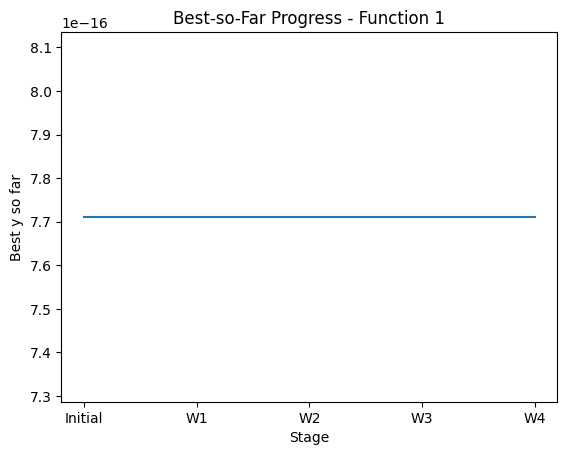

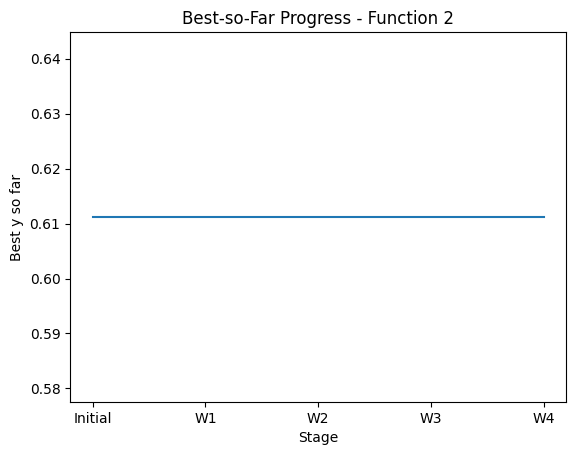

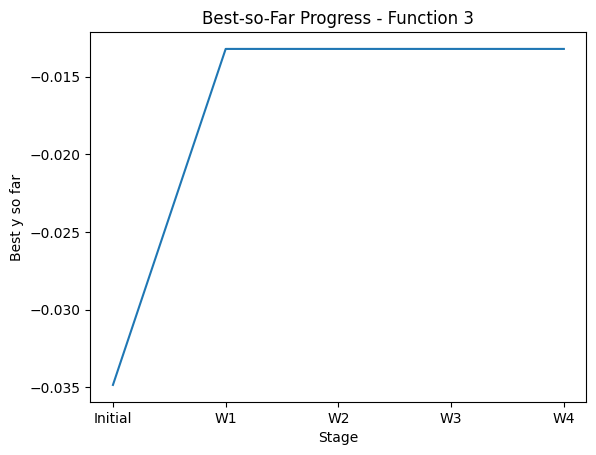

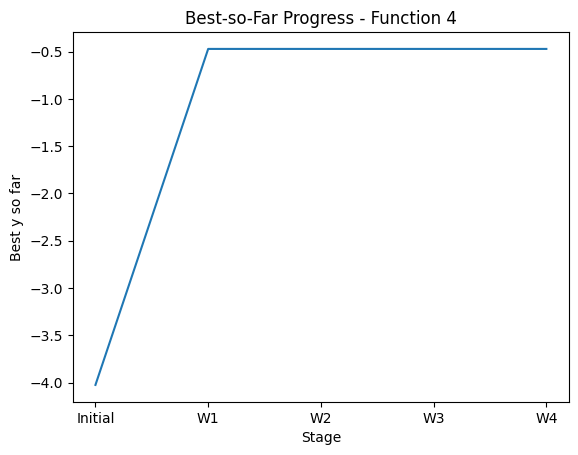

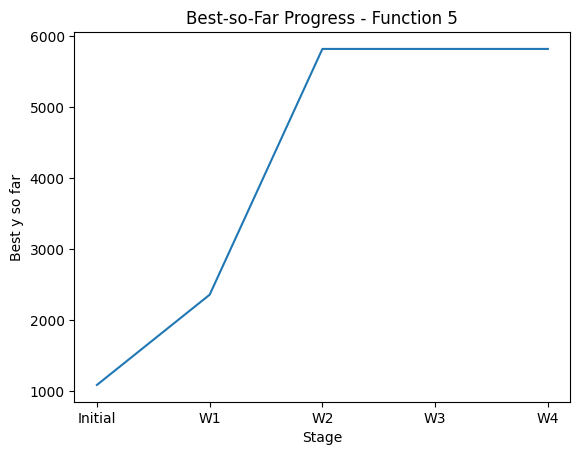

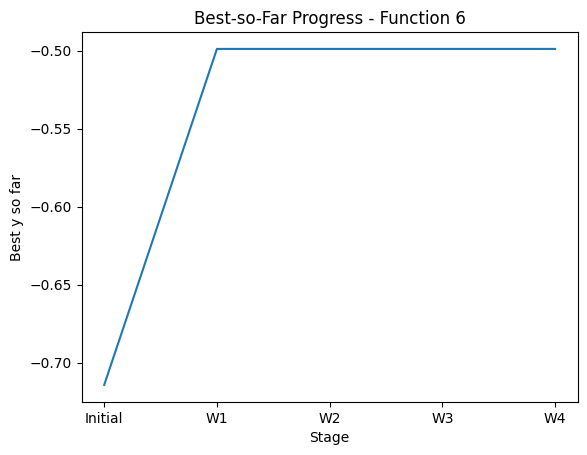

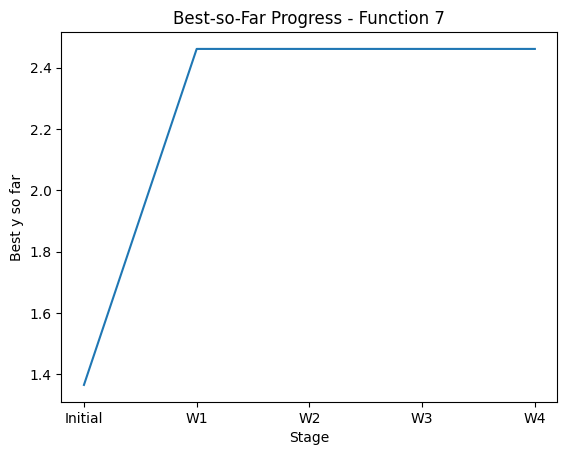

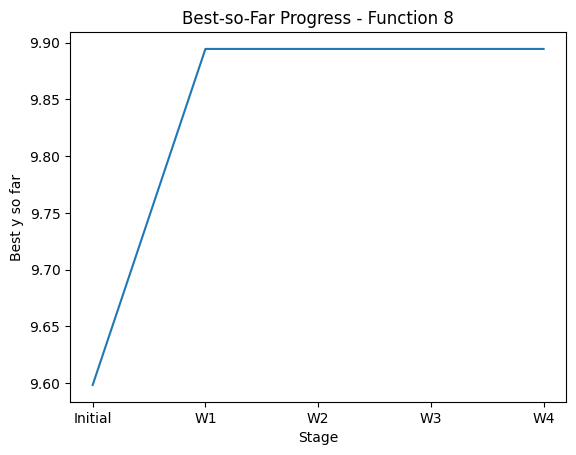

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def plot_progress(func_id, data_raw_dir):
    X0, y0 = load_xy(func_id, data_raw_dir)
    y0 = y0.reshape(-1)

    week_outputs = [
        WEEK1_OUTPUTS[func_id],
        WEEK2_OUTPUTS[func_id],
        WEEK3_OUTPUTS[func_id],
        WEEK4_OUTPUTS[func_id],
    ]

    # Combine initial best + weekly points one by one
    running_best = []
    current_best = np.max(y0)

    running_best.append(current_best)

    for y_w in week_outputs:
        current_best = max(current_best, y_w)
        running_best.append(current_best)

    weeks = ["Initial", "W1", "W2", "W3", "W4"]

    plt.figure()
    plt.plot(weeks, running_best)
    plt.title(f"Best-so-Far Progress - Function {func_id}")
    plt.xlabel("Stage")
    plt.ylabel("Best y so far")
    plt.show()
    


for func_id in range(1, 9):
    plot_progress(func_id, DATA_RAW_DIR)   

### Strategy settings per function

In [70]:
# Week 5: per-function BO settings
STRATEGY = {
    1: {"kappa": 3.0, "n_candidates": 15000, "local_frac": 0.30, "local_sigma": 0.15},  # explore hard
    2: {"kappa": 1.6, "n_candidates": 8000,  "local_frac": 0.40, "local_sigma": 0.08},  # mild exploit
    3: {"kappa": 2.3, "n_candidates": 12000, "local_frac": 0.45, "local_sigma": 0.10},  # balanced
    4: {"kappa": 1.6, "n_candidates": 8000,  "local_frac": 0.60, "local_sigma": 0.06},  # recovery (more local)
    5: {"kappa": 1.2, "n_candidates": 12000,  "local_frac": 0.70, "local_sigma": 0.06},  # exploit (but guarded)
    6: {"kappa": 3.0, "n_candidates": 15000, "local_frac": 0.30, "local_sigma": 0.15},  # explore hard
    7: {"kappa": 1.6, "n_candidates": 9000,  "local_frac": 0.65, "local_sigma": 0.06},  # recovery
    8: {"kappa": 2.3, "n_candidates": 12000, "local_frac": 0.50, "local_sigma": 0.08},  # balanced (hi-dim)
}

# Extra protection against corner collapse (Function 5 only)
# STRATEGY[5]["corner_eps"] = 1e-3
# STRATEGY[5]["corner_penalty"] = 2.0  # if still collapses to corners, try 2.0

# Replace only Function 5 strategy with this:
STRATEGY[5] = {
    "kappa": 1.2,
    "n_candidates": 12000,
    "local_frac": 0.70,
    "local_sigma": 0.06,
    "boundary_guard": 0.02,     # <-- NEW: force candidates into [0.02, 0.98]
    "duplicate_eps": 1e-3,      # <-- NEW: avoid re-picking existing points
}


### Helper: build a mixed candidate pool (global + local around best x)

In [66]:
import numpy as np

def generate_mixed_candidates(
    best_x: np.ndarray,
    *,
    n_candidates: int,
    local_frac: float,
    local_sigma: float,
    seed: int = 42,
) -> np.ndarray:
    """
    Generate a mixture of:
      - global uniform points in [0,1)^d
      - local Gaussian points around best_x (clipped into [0,1))

    Returns:
      Xc shape = (n_candidates, d)
    """
    rng = np.random.default_rng(seed)

    best_x = np.asarray(best_x).reshape(-1)
    dim = best_x.shape[0]

    n_local = int(round(n_candidates * local_frac))
    n_global = n_candidates - n_local

    # 1) Global candidates
    X_global = rng.uniform(0.0, 1.0, size=(n_global, dim))

    # 2) Local candidates (around best_x)
    X_local = rng.normal(loc=best_x, scale=local_sigma, size=(n_local, dim))
    X_local = np.clip(X_local, 0.0, np.nextafter(1.0, 0.0))

    Xc = np.vstack([X_global, X_local])

    # Ensure strictly < 1.0 (portal constraint)
    Xc = np.minimum(Xc, np.nextafter(1.0, 0.0))

    return Xc

### Best-so-far report (Week 4 dataset)

In [67]:
def best_so_far_report(func_id: int, data_raw_dir):
    X_all, y_all = load_xy_with_weeks_1_to_4(func_id, data_raw_dir)

    best_idx = int(np.argmax(y_all))
    best_y = float(y_all[best_idx])
    best_x = X_all[best_idx]

    return best_idx, best_x, best_y, X_all.shape[0], X_all.shape[1]

### Suggest Week 5 point (adaptive BO per function)

In [71]:
def suggest_next_point_week5(func_id: int, data_raw_dir, seed: int = 42):
    # Load data up to Week 4
    X_all, y_all = load_xy_with_weeks_1_to_4(func_id, data_raw_dir)

    # Best so far (used as center for local sampling)
    best_idx = int(np.argmax(y_all))
    best_x = X_all[best_idx]

    cfg = STRATEGY[func_id]

    # Fit GP surrogate
    gp = fit_gp(
        X_all,
        y_all,
        length_scale=0.2,
        kernel_amplitude=1.0,
        random_state=seed,
    )

    # Candidate pool (global + local)
    X_candidates = generate_mixed_candidates(
        best_x,
        n_candidates=cfg["n_candidates"],
        local_frac=cfg["local_frac"],
        local_sigma=cfg["local_sigma"],
        seed=seed + func_id,
    )

    # --- Function 5 only: boundary guard + duplicate avoidance ---
    if func_id == 5:
        guard = float(cfg.get("boundary_guard", 0.02))  # default 2%
        hi = np.nextafter(1.0 - guard, 0.0)

        # Hard restrict candidates away from edges
        X_candidates = np.clip(X_candidates, guard, hi)

    # Acquisition (UCB)
    mean, std = gp.predict(X_candidates, return_std=True)
    scores = acquisition_ucb(mean, std, kappa=cfg["kappa"])

    # --- Function 5 only: avoid duplicates (don’t re-sample existing points) ---
    if func_id == 5:
        dup_eps = float(cfg.get("duplicate_eps", 1e-3))

        # Compute distance from each candidate to nearest existing point
        # (simple but fine at these sizes)
        dists = np.sqrt(((X_candidates[:, None, :] - X_all[None, :, :]) ** 2).sum(axis=2))
        min_dist = dists.min(axis=1)

        # Penalize candidates that are too close to existing samples
        scores = scores - 1e6 * (min_dist < dup_eps).astype(float)

    # Select best candidate
    x_next = X_candidates[int(np.argmax(scores))]

    # Portal formatting + validation
    submission = format_submission(x_next)
    ok, msg = validate_submission_string(submission, dim=X_all.shape[1])
    if not ok:
        raise ValueError(f"Function {func_id}: invalid submission: {msg} -> {submission}")

    return x_next, submission

### Run for all 8 functions (Week 5 submission strings)

In [72]:
results = {}

print("=== Best-so-far (using data up to Week 4) ===")
for func_id in range(1, 9):
    best_idx, best_x, best_y, n_points, dim = best_so_far_report(func_id, DATA_RAW_DIR)
    print(f"Function {func_id}: best_y={best_y:.6f} | best_idx={best_idx} | points={n_points} | dim={dim}")

print("\n=== Week 5 suggestions (READY FOR PORTAL) ===")
for func_id in range(1, 9):
    x_next, submission = suggest_next_point_week5(func_id, DATA_RAW_DIR, seed=42)
    results[func_id] = submission
    print(f"Function {func_id}: {submission}")

=== Best-so-far (using data up to Week 4) ===
Function 1: best_y=0.000000 | best_idx=2 | points=14 | dim=2
Function 2: best_y=0.611205 | best_idx=9 | points=14 | dim=2
Function 3: best_y=-0.013221 | best_idx=15 | points=19 | dim=3
Function 4: best_y=-0.471335 | best_idx=30 | points=34 | dim=4
Function 5: best_y=5823.479461 | best_idx=21 | points=24 | dim=4
Function 6: best_y=-0.498868 | best_idx=20 | points=24 | dim=5
Function 7: best_y=2.460858 | best_idx=30 | points=34 | dim=6
Function 8: best_y=9.894432 | best_idx=40 | points=44 | dim=8

=== Week 5 suggestions (READY FOR PORTAL) ===
Function 1: 0.652299-0.043775
Function 2: 0.718807-0.999999
Function 3: 0.451163-0.676920-0.592177
Function 4: 0.905604-0.077227-0.272570-0.621850
Function 5: 0.980000-0.980000-0.980000-0.980000
Function 6: 0.208776-0.001828-0.479017-0.537405-0.000000
Function 7: 0.099617-0.221403-0.313640-0.206654-0.271980-0.685887
Function 8: 0.062606-0.794599-0.071308-0.396228-0.403033-0.973574-0.035939-0.983739


In [ ]:
import numpy as np

def suggest_next_point_func5_only(data_raw_dir, seed: int = 42):
    func_id = 5

    # ------------------------------------------------------------
    # 1) Load data up to Week 4
    # ------------------------------------------------------------
    X_all, y_all = load_xy_with_weeks_1_to_4(func_id, data_raw_dir)
    n_points, dim = X_all.shape

    # Best-so-far (maximisation)
    best_idx = int(np.argmax(y_all))
    best_y = float(y_all[best_idx])
    best_x = X_all[best_idx].copy()

    print("=== Function 5: data snapshot (up to Week 4) ===")
    print(f"points={n_points}, dim={dim}")
    print(f"best_idx={best_idx}, best_y={best_y:.6f}")
    print(f"best_x={best_x}")

    # ------------------------------------------------------------
    # 2) Strategy knobs (tuned for Function 5 behaviour)
    # ------------------------------------------------------------
    kappa = 1.2                 # more exploit than explore
    n_total = 25000             # total candidate budget (keep reasonable)
    local_frac = 0.70           # mostly local search
    probe_frac = 0.20           # some structured probing
    global_frac = 0.10          # small global exploration
    local_sigma = 0.06          # local radius around best_x
    probe_sigma = 0.15          # bigger jumps for single-dim probes

    # Corner protection (discourage all coords near 1)
    corner_threshold = 0.98     # "near corner" cutoff
    corner_penalty = 2.0        # increase if it still collapses

    # GP hyperparams (keep stable)
    length_scale = 0.2
    kernel_amplitude = 1.0

    # ------------------------------------------------------------
    # 3) Candidate generation helpers
    # ------------------------------------------------------------
    rng = np.random.default_rng(seed)

    def clip_unit(X):
        X = np.clip(X, 0.0, 0.999999)
        return X

    def make_local_candidates(n_local):
        # Gaussian around best_x
        X = best_x + rng.normal(0.0, local_sigma, size=(n_local, dim))
        return clip_unit(X)

    def make_probe_candidates(n_probe):
        """
        Structured probing:
        - Start from best_x
        - Randomly pick 1 dimension and perturb it by a larger sigma
        This helps learn which dimension matters.
        """
        X = np.tile(best_x, (n_probe, 1))
        dims = rng.integers(0, dim, size=n_probe)
        steps = rng.normal(0.0, probe_sigma, size=n_probe)
        X[np.arange(n_probe), dims] = X[np.arange(n_probe), dims] + steps
        return clip_unit(X)

    def make_global_candidates(n_global):
        X = rng.uniform(0.0, 1.0, size=(n_global, dim))
        return clip_unit(X)

    n_local = int(n_total * local_frac)
    n_probe = int(n_total * probe_frac)
    n_global = n_total - n_local - n_probe

    X_candidates = np.vstack([
        make_local_candidates(n_local),
        make_probe_candidates(n_probe),
        make_global_candidates(n_global),
    ])

    # ------------------------------------------------------------
    # 4) Fit GP + score with UCB
    # ------------------------------------------------------------
    gp = fit_gp(
        X_all,
        y_all,
        length_scale=length_scale,
        kernel_amplitude=kernel_amplitude,
        random_state=seed,
    )

    mean, std = gp.predict(X_candidates, return_std=True)
    scores = acquisition_ucb(mean, std, kappa=kappa)

    # ------------------------------------------------------------
    # 5) Corner penalty (soft discouragement)
    # ------------------------------------------------------------
    # If ALL dimensions are >= corner_threshold, subtract penalty.
    near_corner_mask = np.all(X_candidates >= corner_threshold, axis=1)
    scores = scores - corner_penalty * near_corner_mask.astype(float)

    # ------------------------------------------------------------
    # 6) Pick best candidate + format for portal
    # ------------------------------------------------------------
    best_cand_idx = int(np.argmax(scores))
    x_next = X_candidates[best_cand_idx]

    submission = format_submission(x_next)
    ok, msg = validate_submission_string(submission, dim=dim)
    if not ok:
        raise ValueError(f"Function 5 invalid submission: {msg} -> {submission}")

    # Diagnostics
    print("\n=== Function 5: suggestion ===")
    print("x_next:", x_next)
    print("submission:", submission)
    print("Is near-corner(all dims>=0.98)?", bool(np.all(x_next >= corner_threshold)))
    print("Candidate pool sizes:", {"local": n_local, "probe": n_probe, "global": n_global})
    print("Top-5 candidates corner flags:", near_corner_mask[np.argsort(scores)[-5:]].tolist())

    return x_next, submission


# -----------------------------
# RUN ONLY FUNCTION 5
# -----------------------------
x5, s5 = suggest_next_point_func5_only(DATA_RAW_DIR, seed=42)
print("\nREADY FOR PORTAL (Function 5 only):", s5)

=== Function 5: data snapshot (up to Week 4) ===
points=24, dim=4
best_idx=21, best_y=5823.479461
best_x=[0.901642 0.984569 0.982367 0.952999]

=== Function 5: suggestion ===
x_next: [0.999999 0.999999 0.999999 0.999999]
submission: 0.999999-0.999999-0.999999-0.999999
Is near-corner(all dims>=0.98)? True
Candidate pool sizes: {'local': 17500, 'probe': 5000, 'global': 2500}
Top-5 candidates corner flags: [True, True, True, True, True]

READY FOR PORTAL (Function 5 only): 0.999999-0.999999-0.999999-0.999999


In [75]:
import numpy as np

def func5_corner_sanity(data_raw_dir):
    X, y = load_xy_with_weeks_1_to_4(5, data_raw_dir)

    # Top 5 points by y
    top_idx = np.argsort(y)[-5:][::-1]
    X_top = X[top_idx]
    y_top = y[top_idx]

    print("=== Function 5: Top-5 y points ===")
    for rank, (i, xi, yi) in enumerate(zip(top_idx, X_top, y_top), start=1):
        print(f"{rank}) idx={int(i)}  y={float(yi):.6f}  x={np.round(xi, 6)}  min(x)={xi.min():.4f}  mean(x)={xi.mean():.4f}")

    # Correlation per dimension (rough monotonic signal)
    print("\n=== Rough per-dimension correlation with y (Pearson) ===")
    for d in range(X.shape[1]):
        corr = np.corrcoef(X[:, d], y)[0, 1]
        print(f"dim {d}: corr={corr:.3f}")

func5_corner_sanity(DATA_RAW_DIR)

=== Function 5: Top-5 y points ===
1) idx=23  y=5823.479461  x=[0.901642 0.984569 0.982367 0.952999]  min(x)=0.9016  mean(x)=0.9554
2) idx=21  y=5823.479461  x=[0.901642 0.984569 0.982367 0.952999]  min(x)=0.9016  mean(x)=0.9554
3) idx=22  y=5394.580680  x=[0.963141 0.994441 0.801624 0.999286]  min(x)=0.8016  mean(x)=0.9396
4) idx=20  y=2360.040282  x=[0.398348 0.896184 0.926939 0.972836]  min(x)=0.3983  mean(x)=0.7986
5) idx=15  y=1088.859618  x=[0.224189 0.84648  0.879484 0.878516]  min(x)=0.2242  mean(x)=0.7072

=== Rough per-dimension correlation with y (Pearson) ===
dim 0: corr=0.542
dim 1: corr=0.601
dim 2: corr=0.602
dim 3: corr=0.566
